# 统一建模前数据探查：PSI、缺失值、类别变量与异常值

本 Notebook 是逻辑回归、CatBoost、LightGBM、XGBoost 之前的公共数据审查层。它不执行任何模型特有的编码、填补、截尾或变量筛选。

统一原则：
- 沿用原项目 `70% Train / 15% Selection / 15% Test` 的分层随机切分。
- 所有分箱、类别集合、稀有类别和异常阈值只由 Train 学习；Selection/Test 只做验证。
- PSI 在随机切分场景下是稳定性诊断，不因 PSI 高而自动删变量。
- 缺失、极端值和特殊占位值可能携带风险信息；这里只识别和分级，不自动填补、截尾或删除。
- 最后导出固定切分索引、候选变量、复核变量和完整报告，供所有后续模型使用同一份输入政策。

## 1. 配置与依赖

如更换数据，只需修改本单元路径及字段名。阈值是统一初筛口径，不是自动业务决策。

In [1]:
from pathlib import Path
from hashlib import sha256
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

CSV_PATH = Path('/Users/ganlu/Desktop/home-credit-risk-english/data/application_train.csv')
OUTPUT_DIR = Path('/Users/ganlu/Desktop/home-credit-risk-english/machinelearning_final/统一数据探查产物')
TARGET_COL = 'TARGET'
ID_COL = 'SK_ID_CURR'
RANDOM_STATE = 42

PSI_BINS = 10
PSI_EPS = 1e-6
HIGH_MISSING_THRESHOLD = 0.95
QUASI_CONSTANT_THRESHOLD = 0.995
ID_LIKE_RATIO = 0.95
RARE_CATEGORY_PCT = 0.001
RARE_CATEGORY_MIN_N = 50
LOW_CARDINALITY_NUMERIC_MAX = 10
OUTLIER_QUANTILES = (0.005, 0.995)

# 数据集已知的特殊占位值：单独报告，不直接当真实极端值处理。
KNOWN_SPECIAL_VALUES = {'DAYS_EMPLOYED': [365243]}

def file_sha256(path, chunk_size=1024 * 1024):
    digest = sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

## 2. 读取数据、完整性检查与固定样本切分

切分索引会被导出。后续四类模型应读取同一组索引，避免不同 Notebook 各自切分造成不可比。

In [2]:
CSV_PATH = CSV_PATH.expanduser().absolute()
if not CSV_PATH.is_file():
    raise FileNotFoundError(f'数据文件不存在：{CSV_PATH}')

df = pd.read_csv(CSV_PATH, low_memory=False)
if not df.columns.is_unique:
    raise ValueError('列名不唯一，必须先修正。')
if TARGET_COL not in df or ID_COL not in df:
    raise ValueError(f'必须包含 {TARGET_COL} 和 {ID_COL}。')
if df[TARGET_COL].isna().any() or set(df[TARGET_COL].unique()) != {0, 1}:
    raise ValueError('TARGET 必须非空且同时只包含 0/1。')
if df[ID_COL].isna().any() or not df[ID_COL].is_unique:
    raise ValueError('当前流程要求一客户一行且 ID 唯一；重复客户需另行设计分组/时间切分。')

DATA_SHA256 = file_sha256(CSV_PATH)
feature_cols = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]
X = df.loc[:, feature_cols]
y = df[TARGET_COL].astype('int8')
idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
selection_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y.iloc[temp_idx], random_state=RANDOM_STATE
)

def take_split(rows):
    return X.iloc[rows].reset_index(drop=True), y.iloc[rows].reset_index(drop=True)

X_train, y_train = take_split(train_idx)
X_selection, y_selection = take_split(selection_idx)
X_test, y_test = take_split(test_idx)

dataset_overview = pd.Series({
    'source': str(CSV_PATH), 'sha256': DATA_SHA256, 'rows': len(df),
    'columns_including_id_target': df.shape[1], 'features': len(feature_cols),
    'bad_n': int(y.sum()), 'bad_rate': float(y.mean()),
    'duplicate_rows': int(df.duplicated().sum()),
    'unique_id': int(df[ID_COL].nunique()),
    'memory_mb': float(df.memory_usage(deep=True).sum() / 1024**2)
})
split_overview = pd.DataFrame({
    'sample': ['Train', 'Selection', 'Test'],
    'n': [len(y_train), len(y_selection), len(y_test)],
    'share': [len(y_train)/len(y), len(y_selection)/len(y), len(y_test)/len(y)],
    'bad_n': [int(y_train.sum()), int(y_selection.sum()), int(y_test.sum())],
    'bad_rate': [y_train.mean(), y_selection.mean(), y_test.mean()]
})
display(dataset_overview.to_frame('value'))
display(split_overview)

,value
source,/Users/ganlu/Desktop/home-credit-risk-english/...
sha256,52e96b895b1112e1c853f670e58372719c8441c5ed1c57...
rows,307511
columns_including_id_target,122
features,120
bad_n,24825
bad_rate,0.080729
duplicate_rows,0
unique_id,307511
memory_mb,536.691602


,sample,n,share,bad_n,bad_rate
0,Train,215257,0.699998,17377,0.080727
1,Selection,46127,0.150001,3724,0.080734
2,Test,46127,0.150001,3724,0.080734


## 3. 全字段基础质量画像

`hard_drop` 仅标记全缺失、常量和高度疑似 ID 的类别字段；高缺失、近常量、低基数数值字段只进入复核清单。

In [3]:
def is_physical_categorical(s):
    return (
        pd.api.types.is_object_dtype(s)
        or pd.api.types.is_string_dtype(s)
        or isinstance(s.dtype, pd.CategoricalDtype)
        or pd.api.types.is_bool_dtype(s)
    )

def scan_feature_quality(frame, target):
    rows = []
    for col in frame.columns:
        s = frame[col]
        miss = s.isna()
        n_unique = int(s.nunique(dropna=True))
        top_frequency = float(s.value_counts(dropna=False, normalize=True).iloc[0])
        is_cat = is_physical_categorical(s)
        unique_ratio = n_unique / max(int((~miss).sum()), 1)
        if miss.all():
            hard_reason = 'all_missing'
        elif s.nunique(dropna=False) <= 1:
            hard_reason = 'constant'
        elif is_cat and unique_ratio > ID_LIKE_RATIO:
            hard_reason = 'id_like_categorical'
        else:
            hard_reason = ''
        warnings_ = []
        if miss.mean() > HIGH_MISSING_THRESHOLD:
            warnings_.append('high_missing')
        if top_frequency > QUASI_CONSTANT_THRESHOLD and not hard_reason:
            warnings_.append('quasi_constant')
        if (not is_cat) and n_unique <= LOW_CARDINALITY_NUMERIC_MAX:
            warnings_.append('low_card_numeric_review')
        rows.append({
            'feature': col, 'dtype': str(s.dtype),
            'physical_categorical': is_cat,
            'low_card_numeric_candidate': (not is_cat) and n_unique <= LOW_CARDINALITY_NUMERIC_MAX,
            'n_unique_nonmissing': n_unique, 'unique_ratio_nonmissing': unique_ratio,
            'missing_n': int(miss.sum()), 'missing_rate': float(miss.mean()),
            'top_frequency': top_frequency,
            'bad_rate_missing': float(target[miss].mean()) if miss.any() else np.nan,
            'bad_rate_nonmissing': float(target[~miss].mean()) if (~miss).any() else np.nan,
            'hard_drop': bool(hard_reason), 'hard_drop_reason': hard_reason,
            'quality_warning': '|'.join(warnings_)
        })
    return pd.DataFrame(rows)

feature_report = scan_feature_quality(X_train, y_train)
physical_cat_cols = feature_report.loc[feature_report.physical_categorical, 'feature'].tolist()
numeric_cols = feature_report.loc[~feature_report.physical_categorical, 'feature'].tolist()
low_card_numeric_candidates = feature_report.loc[feature_report.low_card_numeric_candidate, 'feature'].tolist()
hard_drop_features = feature_report.loc[feature_report.hard_drop, 'feature'].tolist()

print('原始特征数:', len(feature_cols))
print('物理类别变量:', len(physical_cat_cols), '数值变量:', len(numeric_cols))
print('低基数数值变量（建议按模型/业务复核类型）:', len(low_card_numeric_candidates))
print('硬剔除候选:', len(hard_drop_features))
display(feature_report.sort_values(['hard_drop', 'missing_rate', 'top_frequency'], ascending=False).head(30))

原始特征数: 120
物理类别变量: 16 数值变量: 104
低基数数值变量（建议按模型/业务复核类型）: 40
硬剔除候选: 0


,feature,dtype,physical_categorical,low_card_numeric_candidate,n_unique_nonmissing,unique_ratio_nonmissing,missing_n,missing_rate,top_frequency,bad_rate_missing,bad_rate_nonmissing,hard_drop,hard_drop_reason,quality_warning
46,COMMONAREA_AVG,float64,False,False,2964,0.045630,150300,0.698235,0.698235,0.085602,0.069446,False,,
60,COMMONAREA_MODE,float64,False,False,2908,0.044768,150300,0.698235,0.698235,0.085602,0.069446,False,,
74,COMMONAREA_MEDI,float64,False,False,2982,0.045907,150300,0.698235,0.698235,0.085602,0.069446,False,,
54,NONLIVINGAPARTMENTS_AVG,float64,False,False,345,0.005235,149354,0.693840,0.693840,0.085649,0.069572,False,,
68,NONLIVINGAPARTMENTS_MODE,float64,False,False,148,0.002246,149354,0.693840,0.693840,0.085649,0.069572,False,,
82,NONLIVINGAPARTMENTS_MEDI,float64,False,False,190,0.002883,149354,0.693840,0.693840,0.085649,0.069572,False,,
84,FONDKAPREMONT_MODE,str,True,False,4,0.000059,147099,0.683365,0.683365,0.085908,0.069544,False,,
52,LIVINGAPARTMENTS_AVG,float64,False,False,1761,0.025818,147049,0.683132,0.683132,0.085944,0.069479,False,,
66,LIVINGAPARTMENTS_MODE,float64,False,False,715,0.010483,147049,0.683132,0.683132,0.085944,0.069479,False,,
80,LIVINGAPARTMENTS_MEDI,float64,False,False,1063,0.015585,147049,0.683132,0.683132,0.085944,0.069479,False,,


## 4. 缺失值探查

除缺失率外，统一比较 Train 中“缺失/非缺失”的坏样本率。差异只表示关联，不表示因果，也不意味着应该直接填补。

In [4]:
missing_report = feature_report[[
    'feature', 'dtype', 'missing_n', 'missing_rate',
    'bad_rate_missing', 'bad_rate_nonmissing'
]].copy()
missing_report['bad_rate_gap_missing_minus_nonmissing'] = (
    missing_report['bad_rate_missing'] - missing_report['bad_rate_nonmissing']
)
missing_report['abs_bad_rate_gap'] = missing_report['bad_rate_gap_missing_minus_nonmissing'].abs()
missing_report['selection_missing_rate'] = X_selection.isna().mean().reindex(missing_report.feature).to_numpy()
missing_report['test_missing_rate'] = X_test.isna().mean().reindex(missing_report.feature).to_numpy()
missing_report['max_missing_rate_gap_vs_train'] = np.maximum(
    (missing_report.selection_missing_rate - missing_report.missing_rate).abs(),
    (missing_report.test_missing_rate - missing_report.missing_rate).abs(),
)
missing_report = missing_report.sort_values(['missing_rate', 'abs_bad_rate_gap'], ascending=False).reset_index(drop=True)
display(missing_report.loc[missing_report.missing_n > 0].head(40))

,feature,dtype,missing_n,missing_rate,bad_rate_missing,bad_rate_nonmissing,bad_rate_gap_missing_minus_nonmissing,abs_bad_rate_gap,selection_missing_rate,test_missing_rate,max_missing_rate_gap_vs_train
0,COMMONAREA_AVG,float64,150300,0.698235,0.085602,0.069446,0.016156,0.016156,0.699222,0.700501,0.002266
1,COMMONAREA_MODE,float64,150300,0.698235,0.085602,0.069446,0.016156,0.016156,0.699222,0.700501,0.002266
2,COMMONAREA_MEDI,float64,150300,0.698235,0.085602,0.069446,0.016156,0.016156,0.699222,0.700501,0.002266
3,NONLIVINGAPARTMENTS_AVG,float64,149354,0.693840,0.085649,0.069572,0.016077,0.016077,0.695038,0.695905,0.002064
4,NONLIVINGAPARTMENTS_MODE,float64,149354,0.693840,0.085649,0.069572,0.016077,0.016077,0.695038,0.695905,0.002064
5,NONLIVINGAPARTMENTS_MEDI,float64,149354,0.693840,0.085649,0.069572,0.016077,0.016077,0.695038,0.695905,0.002064
6,FONDKAPREMONT_MODE,str,147099,0.683365,0.085908,0.069544,0.016364,0.016364,0.684458,0.685585,0.002221
7,LIVINGAPARTMENTS_AVG,float64,147049,0.683132,0.085944,0.069479,0.016465,0.016465,0.684458,0.684588,0.001456
8,LIVINGAPARTMENTS_MODE,float64,147049,0.683132,0.085944,0.069479,0.016465,0.016465,0.684458,0.684588,0.001456
9,LIVINGAPARTMENTS_MEDI,float64,147049,0.683132,0.085944,0.069479,0.016465,0.016465,0.684458,0.684588,0.001456


## 5. 类别变量探查

物理类别字段和低基数数值候选分开保留。类别明细包含 Train 样本量、占比、坏样本率、稀有类别标记，以及 Selection/Test 未见类别。后续模型自行决定原生类别、One-Hot 或 WOE。

In [5]:
MISSING_LABEL = '__MISSING__'
RARE_LABEL = '__RARE__'
UNSEEN_LABEL = '__UNSEEN__'

def category_text(s):
    return ('V:' + s.astype('string')).fillna(MISSING_LABEL)

category_summary_rows = []
category_level_parts = []
category_scan_cols = physical_cat_cols + [c for c in low_card_numeric_candidates if c not in physical_cat_cols]
for col in category_scan_cols:
    train_text = category_text(X_train[col])
    selection_text = category_text(X_selection[col])
    test_text = category_text(X_test[col])
    known = set(train_text.unique())
    rare_cut = max(RARE_CATEGORY_MIN_N, int(np.ceil(len(train_text) * RARE_CATEGORY_PCT)))
    counts = train_text.value_counts(dropna=False)
    rare_levels = set(counts[counts < rare_cut].index) - {MISSING_LABEL}
    temp = pd.DataFrame({'level': train_text, 'target': y_train})
    detail = temp.groupby('level', dropna=False, observed=False)['target'].agg(['count', 'sum', 'mean']).reset_index()
    detail = detail.rename(columns={'sum': 'bad_n', 'mean': 'bad_rate'})
    detail.insert(0, 'feature', col)
    detail['share'] = detail['count'] / len(train_text)
    detail['is_missing'] = detail['level'].eq(MISSING_LABEL)
    detail['is_rare'] = detail['level'].isin(rare_levels)
    category_level_parts.append(detail.sort_values('count', ascending=False))
    category_summary_rows.append({
        'feature': col,
        'category_kind': 'physical_categorical' if col in physical_cat_cols else 'low_card_numeric_candidate',
        'levels_nonmissing_train': int(X_train[col].nunique(dropna=True)),
        'missing_rate_train': float(X_train[col].isna().mean()),
        'top_level_share_train': float(counts.iloc[0] / len(train_text)),
        'rare_level_n': len(rare_levels),
        'rare_sample_share_train': float(train_text.isin(rare_levels).mean()),
        'selection_unseen_level_n': len(set(selection_text.unique()) - known),
        'selection_unseen_sample_rate': float((~selection_text.isin(known)).mean()),
        'test_unseen_level_n': len(set(test_text.unique()) - known),
        'test_unseen_sample_rate': float((~test_text.isin(known)).mean()),
    })

category_summary = pd.DataFrame(category_summary_rows).sort_values('levels_nonmissing_train', ascending=False).reset_index(drop=True)
category_levels = pd.concat(category_level_parts, ignore_index=True) if category_level_parts else pd.DataFrame()
display(category_summary)
print('低基数数值候选（未自动转为类别）:', low_card_numeric_candidates)

,feature,category_kind,levels_nonmissing_train,missing_rate_train,top_level_share_train,rare_level_n,rare_sample_share_train,selection_unseen_level_n,selection_unseen_sample_rate,test_unseen_level_n,test_unseen_sample_rate
0,ORGANIZATION_TYPE,physical_categorical,58,0.000000,0.221047,10,0.004200,0,0.000000,0,0.000000
1,OCCUPATION_TYPE,physical_categorical,18,0.313486,0.313486,0,0.000000,0,0.000000,0,0.000000
2,AMT_REQ_CREDIT_BUREAU_QRT,low_card_numeric_candidate,10,0.135099,0.700999,5,0.000358,0,0.000000,1,0.000022
3,DEF_30_CNT_SOCIAL_CIRCLE,low_card_numeric_candidate,10,0.003317,0.882610,6,0.001013,0,0.000000,0,0.000000
4,AMT_REQ_CREDIT_BUREAU_DAY,low_card_numeric_candidate,9,0.135099,0.860121,7,0.000632,0,0.000000,0,0.000000
5,DEF_60_CNT_SOCIAL_CIRCLE,low_card_numeric_candidate,9,0.003317,0.913392,5,0.000483,0,0.000000,0,0.000000
6,AMT_REQ_CREDIT_BUREAU_WEEK,low_card_numeric_candidate,9,0.135099,0.837353,7,0.000999,0,0.000000,0,0.000000
7,NAME_INCOME_TYPE,physical_categorical,8,0.000000,0.515588,4,0.000172,0,0.000000,0,0.000000
8,NAME_TYPE_SUITE,physical_categorical,7,0.004186,0.808750,1,0.000920,0,0.000000,0,0.000000
9,WEEKDAY_APPR_PROCESS_START,physical_categorical,7,0.000000,0.175725,0,0.000000,0,0.000000,0,0.000000


低基数数值候选（未自动转为类别）: ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_QRT']


## 6. PSI：Train 拟合分箱，Selection/Test 验证

数值字段使用 Train 等频边界；类别字段将 Train 稀有类别合并，其他样本的新类别记为 `__UNSEEN__`。常用解释：`<0.10` 稳定，`0.10–0.25` 需关注，`>=0.25` 明显偏移。阈值不是自动删变量规则。

In [6]:
def fit_psi_spec(s, bins=PSI_BINS):
    if pd.api.types.is_numeric_dtype(s) and s.dropna().nunique() >= 2:
        values = pd.to_numeric(s, errors='coerce').replace([np.inf, -np.inf], np.nan)
        edges = np.unique(np.nanquantile(values.dropna(), np.linspace(0, 1, bins + 1))).astype(float)
        if len(edges) >= 3:
            edges[0], edges[-1] = -np.inf, np.inf
            return {'type': 'numeric', 'edges': edges}
    labels = category_text(s)
    counts = labels.value_counts()
    rare_cut = max(RARE_CATEGORY_MIN_N, int(np.ceil(len(labels) * RARE_CATEGORY_PCT)))
    rare = set(counts[counts < rare_cut].index) - {MISSING_LABEL}
    known = set(labels.unique()) - rare
    return {'type': 'categorical', 'known': known, 'rare': rare}

def apply_psi_spec(s, spec, reference=False):
    if spec['type'] == 'numeric':
        values = pd.to_numeric(s, errors='coerce').replace([np.inf, -np.inf], np.nan)
        labels = pd.cut(values, bins=spec['edges'], include_lowest=True, duplicates='drop').astype('string')
        return labels.fillna(MISSING_LABEL)
    labels = category_text(s)
    labels = labels.where(~labels.isin(spec['rare']), RARE_LABEL)
    if not reference:
        allowed = spec['known'] | {RARE_LABEL, MISSING_LABEL}
        labels = labels.where(labels.isin(allowed), UNSEEN_LABEL)
    return labels

def psi_detail_table(reference_labels, current_labels, feature, comparison, eps=PSI_EPS):
    ref_count = pd.Series(reference_labels).value_counts(dropna=False)
    cur_count = pd.Series(current_labels).value_counts(dropna=False)
    levels = ref_count.index.union(cur_count.index)
    out = pd.DataFrame({'bin': levels})
    out['reference_n'] = out['bin'].map(ref_count).fillna(0).astype(int)
    out['current_n'] = out['bin'].map(cur_count).fillna(0).astype(int)
    out['reference_pct'] = (out.reference_n / max(out.reference_n.sum(), 1)).clip(lower=eps)
    out['current_pct'] = (out.current_n / max(out.current_n.sum(), 1)).clip(lower=eps)
    out['psi_component'] = (out.reference_pct - out.current_pct) * np.log(out.reference_pct / out.current_pct)
    out.insert(0, 'comparison', comparison)
    out.insert(0, 'feature', feature)
    return out

psi_rows, psi_detail_parts, psi_specs = [], [], {}
for col in feature_cols:
    spec = fit_psi_spec(X_train[col])
    psi_specs[col] = spec
    ref_labels = apply_psi_spec(X_train[col], spec, reference=True)
    values = {}
    for comparison, frame in [('selection', X_selection), ('test', X_test)]:
        cur_labels = apply_psi_spec(frame[col], spec, reference=False)
        detail = psi_detail_table(ref_labels, cur_labels, col, comparison)
        psi_detail_parts.append(detail)
        values[f'psi_{comparison}'] = float(detail.psi_component.sum())
    max_psi = max(values.values())
    psi_rows.append({
        'feature': col, 'psi_type': spec['type'], **values, 'max_psi': max_psi,
        'psi_flag': 'shift' if max_psi >= 0.25 else ('review' if max_psi >= 0.10 else 'stable')
    })

psi_summary = pd.DataFrame(psi_rows).sort_values('max_psi', ascending=False).reset_index(drop=True)
psi_detail = pd.concat(psi_detail_parts, ignore_index=True)
display(psi_summary.head(30))

,feature,psi_type,psi_selection,psi_test,max_psi,psi_flag
0,ORGANIZATION_TYPE,categorical,0.001352,0.001381,0.001381,stable
1,OCCUPATION_TYPE,categorical,0.000698,0.000335,0.000698,stable
2,LIVINGAREA_MEDI,numeric,0.000174,0.000482,0.000482,stable
3,DAYS_ID_PUBLISH,numeric,0.000112,0.000467,0.000467,stable
4,LIVINGAREA_AVG,numeric,0.000119,0.000460,0.000460,stable
5,DAYS_LAST_PHONE_CHANGE,numeric,0.000441,0.000325,0.000441,stable
6,EXT_SOURCE_3,numeric,0.000397,0.000384,0.000397,stable
7,COMMONAREA_AVG,numeric,0.000381,0.000148,0.000381,stable
8,AMT_INCOME_TOTAL,numeric,0.000143,0.000360,0.000360,stable
9,NONLIVINGAREA_MEDI,numeric,0.000349,0.000190,0.000349,stable


## 7. 数值异常、特殊占位值与业务规则

统计异常同时给出 IQR 和 Train 的 0.5%/99.5% 边界。它们适合定位变量，不等同于错误值。业务规则是更强的核验信号，但仍需结合字段定义确认。

In [7]:
def numeric_anomaly_scan(train, selection, test, columns):
    rows = []
    for col in columns:
        raw = pd.to_numeric(train[col], errors='coerce')
        inf_mask = np.isinf(raw)
        s = raw.mask(inf_mask)
        valid = s.dropna()
        if valid.empty:
            continue
        q005, q25, median, q75, q995 = valid.quantile([OUTLIER_QUANTILES[0], .25, .5, .75, OUTLIER_QUANTILES[1]])
        iqr = q75 - q25
        iqr_low, iqr_high = q25 - 1.5 * iqr, q75 + 1.5 * iqr
        iqr_outlier = (s < iqr_low) | (s > iqr_high)
        extreme = (s < q005) | (s > q995)
        special_counts = {str(v): int(s.eq(v).sum()) for v in KNOWN_SPECIAL_VALUES.get(col, [])}
        row = {
            'feature': col, 'valid_n': int(valid.size), 'inf_n': int(inf_mask.sum()),
            'min': float(valid.min()), 'q005': float(q005), 'q25': float(q25),
            'median': float(median), 'q75': float(q75), 'q995': float(q995), 'max': float(valid.max()),
            'iqr_low': float(iqr_low), 'iqr_high': float(iqr_high),
            'iqr_outlier_n': int(iqr_outlier.sum()), 'iqr_outlier_rate': float(iqr_outlier.mean()),
            'tail_extreme_n': int(extreme.sum()), 'tail_extreme_rate': float(extreme.mean()),
            'known_special_counts': json.dumps(special_counts, ensure_ascii=False),
        }
        for sample_name, frame in [('selection', selection), ('test', test)]:
            other = pd.to_numeric(frame[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
            row[f'{sample_name}_outside_train_minmax_rate'] = float(((other < valid.min()) | (other > valid.max())).mean())
            row[f'{sample_name}_outside_train_q005_q995_rate'] = float(((other < q005) | (other > q995)).mean())
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['iqr_outlier_rate', 'tail_extreme_rate'], ascending=False).reset_index(drop=True)

numeric_anomaly_report = numeric_anomaly_scan(X_train, X_selection, X_test, numeric_cols)

def add_business_rule(rows, frame, feature, rule, invalid_mask):
    if feature not in frame:
        return
    valid_mask = frame[feature].notna()
    invalid_mask = invalid_mask.fillna(False) & valid_mask
    rows.append({
        'feature': feature, 'rule': rule, 'checked_nonmissing_n': int(valid_mask.sum()),
        'invalid_n': int(invalid_mask.sum()), 'invalid_rate_all': float(invalid_mask.mean()),
        'bad_rate_invalid': float(y_train[invalid_mask].mean()) if invalid_mask.any() else np.nan,
    })

business_rows = []
if 'DAYS_BIRTH' in X_train:
    add_business_rule(business_rows, X_train, 'DAYS_BIRTH', '应为负数', X_train['DAYS_BIRTH'] >= 0)
if 'DAYS_EMPLOYED' in X_train:
    add_business_rule(business_rows, X_train, 'DAYS_EMPLOYED', '应<=0；365243为已知特殊占位值', (X_train['DAYS_EMPLOYED'] > 0) & (X_train['DAYS_EMPLOYED'] != 365243))
for col in [c for c in X_train.columns if c.startswith('EXT_SOURCE_')]:
    s = pd.to_numeric(X_train[col], errors='coerce')
    add_business_rule(business_rows, X_train, col, '应位于[0, 1]', (s < 0) | (s > 1))
for col in [c for c in X_train.columns if c.startswith(('AMT_', 'CNT_'))]:
    s = pd.to_numeric(X_train[col], errors='coerce')
    add_business_rule(business_rows, X_train, col, '金额/计数字段不应为负', s < 0)
business_anomaly_report = pd.DataFrame(business_rows).sort_values('invalid_rate_all', ascending=False).reset_index(drop=True)

display(numeric_anomaly_report.head(30))
display(business_anomaly_report.loc[business_anomaly_report.invalid_n > 0] if len(business_anomaly_report) else business_anomaly_report)

,feature,valid_n,inf_n,min,q005,q25,median,q75,q995,max,iqr_low,iqr_high,iqr_outlier_n,iqr_outlier_rate,tail_extreme_n,tail_extreme_rate,known_special_counts,selection_outside_train_minmax_rate,selection_outside_train_q005_q995_rate,test_outside_train_minmax_rate,test_outside_train_q005_q995_rate
0,REGION_RATING_CLIENT,215257,0,1.000000,1.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,56411,0.262063,0,0.000000,{},0.000000,0.000000,0.000000,0.000000
1,REGION_RATING_CLIENT_W_CITY,215257,0,1.000000,1.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,54693,0.254082,0,0.000000,{},0.000000,0.000000,0.000000,0.000000
2,DAYS_EMPLOYED,215257,0,"-17,583.000000","-12,246.720000","-2,761.000000","-1,213.000000",-289.000000,"365,243.000000","365,243.000000","-6,469.000000","3,419.000000",50600,0.235068,1077,0.005003,"{""365243"": 38756}",0.000022,0.004943,0.000000,0.005441
3,REG_CITY_NOT_WORK_CITY,215257,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,49560,0.230236,0,0.000000,{},0.000000,0.000000,0.000000,0.000000
4,FLAG_WORK_PHONE,215257,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,42851,0.199069,0,0.000000,{},0.000000,0.000000,0.000000,0.000000
5,FLAG_EMP_PHONE,215257,0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,38766,0.180092,0,0.000000,{},0.000000,0.000000,0.000000,0.000000
6,LIVE_CITY_NOT_WORK_CITY,215257,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,38739,0.179966,0,0.000000,{},0.000000,0.000000,0.000000,0.000000
7,AMT_REQ_CREDIT_BUREAU_QRT,186176,0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,19.000000,0.000000,0.000000,35281,0.163902,423,0.001965,{},0.000000,0.001821,0.000022,0.001669
8,AMT_REQ_CREDIT_BUREAU_MON,186176,0,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,27.000000,0.000000,0.000000,30497,0.141677,842,0.003912,{},0.000000,0.004423,0.000000,0.003642
9,DEF_30_CNT_SOCIAL_CIRCLE,214543,0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,34.000000,0.000000,0.000000,24555,0.114073,1050,0.004878,{},0.000000,0.005095,0.000000,0.004986


,feature,rule,checked_nonmissing_n,invalid_n,invalid_rate_all,bad_rate_invalid


## 8. 统一决策表与快速可视化

`candidate_features` 只排除硬剔除项；`review_features` 需要在具体模型前确认处理方式。报告不会把高缺失、PSI、稀有类别或极端值直接转化为删除命令。

,feature_n
recommended_action,
keep_candidate,72
review,48


,feature,dtype,physical_categorical,low_card_numeric_candidate,n_unique_nonmissing,unique_ratio_nonmissing,missing_n,missing_rate,top_frequency,bad_rate_missing,bad_rate_nonmissing,hard_drop,hard_drop_reason,quality_warning,psi_type,psi_selection,psi_test,max_psi,psi_flag,inf_n,iqr_outlier_rate,tail_extreme_rate,known_special_counts,levels_nonmissing_train,rare_sample_share_train,selection_unseen_sample_rate,test_unseen_sample_rate,business_invalid_n,business_max_invalid_rate,review_reason,recommended_action
9,NONLIVINGAREA_MEDI,float64,False,False,3083,0.031889,118577,0.550862,0.550862,0.090017,0.069332,False,,,numeric,0.000349,0.000190,0.000349,stable,0.000000,0.055761,0.002248,{},NaN,NaN,NaN,NaN,NaN,NaN,high_iqr_outlier_rate,review
16,FLAG_DOCUMENT_13,int64,False,True,2,0.000009,0,0.000000,0.996674,NaN,0.080727,False,,quasi_constant|low_card_numeric_review,categorical,0.000018,0.000302,0.000302,stable,0.000000,0.003326,0.003326,{},2.000000,0.000000,0.000000,0.000000,NaN,NaN,quasi_constant|low_card_numeric_review,review
27,NONLIVINGAREA_AVG,float64,False,False,3042,0.031465,118577,0.550862,0.550862,0.090017,0.069332,False,,,numeric,0.000261,0.000184,0.000261,stable,0.000000,0.053378,0.002248,{},NaN,NaN,NaN,NaN,NaN,NaN,high_iqr_outlier_rate,review
33,DAYS_EMPLOYED,int64,False,False,11770,0.054679,0,0.000000,0.180045,NaN,0.080727,False,,,numeric,0.000205,0.000246,0.000246,stable,0.000000,0.235068,0.005003,"{""365243"": 38756}",NaN,NaN,NaN,NaN,0.000000,0.000000,high_iqr_outlier_rate|known_special_value,review
42,NONLIVINGAREA_MODE,float64,False,False,3090,0.031961,118577,0.550862,0.550862,0.090017,0.069332,False,,,numeric,0.000202,0.000194,0.000202,stable,0.000000,0.061159,0.002244,{},NaN,NaN,NaN,NaN,NaN,NaN,high_iqr_outlier_rate,review
66,LIVE_REGION_NOT_WORK_REGION,int64,False,True,2,0.000009,0,0.000000,0.958789,NaN,0.080727,False,,low_card_numeric_review,categorical,0.000122,0.000059,0.000122,stable,0.000000,0.041211,0.000000,{},2.000000,0.000000,0.000000,0.000000,NaN,NaN,low_card_numeric_review,review
67,OBS_60_CNT_SOCIAL_CIRCLE,float64,False,False,32,0.000149,714,0.003317,0.534640,0.039216,0.080865,False,,,numeric,0.000122,0.000025,0.000122,stable,0.000000,0.063519,0.003916,{},NaN,NaN,NaN,NaN,NaN,NaN,high_iqr_outlier_rate,review
68,FLAG_DOCUMENT_15,int64,False,True,2,0.000009,0,0.000000,0.998876,NaN,0.080727,False,,quasi_constant|low_card_numeric_review,categorical,0.000118,0.000026,0.000118,stable,0.000000,0.001124,0.001124,{},2.000000,0.000000,0.000000,0.000000,NaN,NaN,quasi_constant|low_card_numeric_review,review
69,OBS_30_CNT_SOCIAL_CIRCLE,float64,False,False,32,0.000149,714,0.003317,0.532155,0.039216,0.080865,False,,,numeric,0.000114,0.000020,0.000114,stable,0.000000,0.064848,0.004070,{},NaN,NaN,NaN,NaN,NaN,NaN,high_iqr_outlier_rate,review
70,DEF_60_CNT_SOCIAL_CIRCLE,float64,False,True,9,0.000042,714,0.003317,0.913392,0.039216,0.080865,False,,low_card_numeric_review,categorical,0.000080,0.000112,0.000112,stable,0.000000,0.083291,0.002425,{},9.000000,0.000483,0.000000,0.000000,NaN,NaN,low_card_numeric_review,review


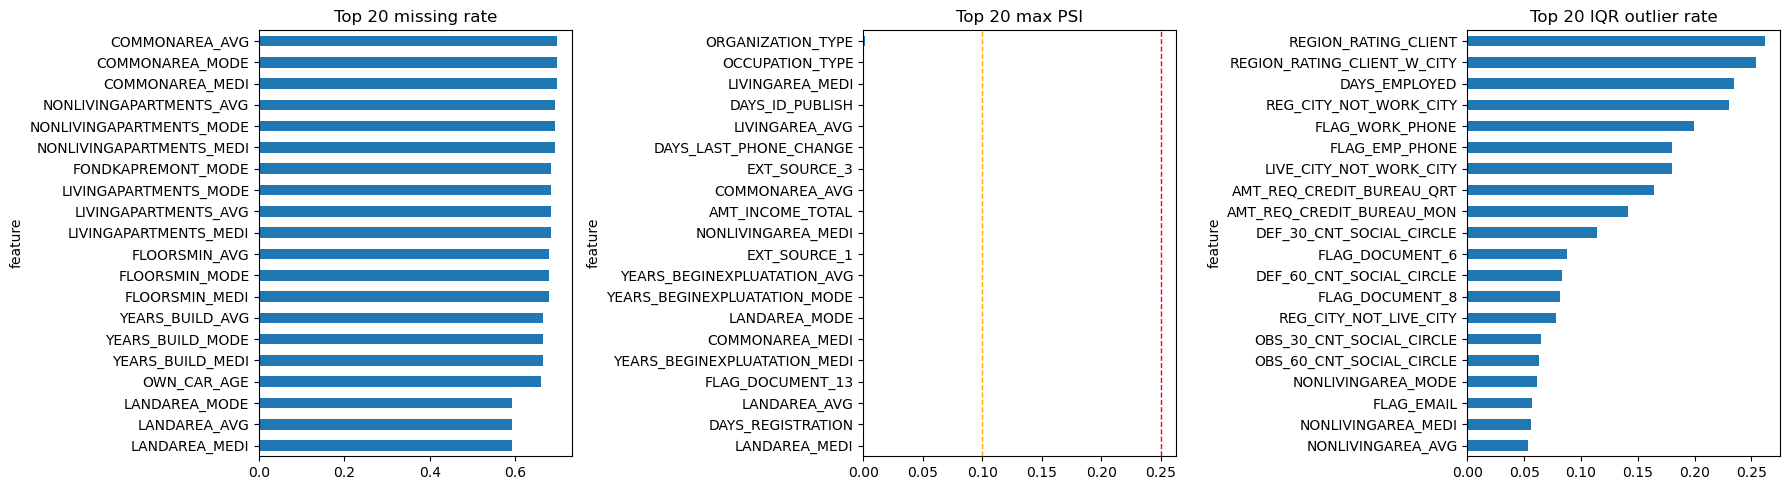

In [8]:
decision_report = feature_report.merge(psi_summary, on='feature', how='left')
decision_report = decision_report.merge(
    numeric_anomaly_report[['feature', 'inf_n', 'iqr_outlier_rate', 'tail_extreme_rate', 'known_special_counts']],
    on='feature', how='left'
)
if len(category_summary):
    decision_report = decision_report.merge(
        category_summary[['feature', 'levels_nonmissing_train', 'rare_sample_share_train', 'selection_unseen_sample_rate', 'test_unseen_sample_rate']],
        on='feature', how='left'
    )
if len(business_anomaly_report):
    business_by_feature = business_anomaly_report.groupby('feature', as_index=False).agg(
        business_invalid_n=('invalid_n', 'sum'),
        business_max_invalid_rate=('invalid_rate_all', 'max'),
    )
    decision_report = decision_report.merge(business_by_feature, on='feature', how='left')

def collect_review_reasons(row):
    reasons = []
    if row['quality_warning']:
        reasons.extend(row['quality_warning'].split('|'))
    if row.get('psi_flag') in {'review', 'shift'}:
        reasons.append(f"psi_{row['psi_flag']}")
    if pd.notna(row.get('inf_n')) and row.get('inf_n', 0) > 0:
        reasons.append('infinite_values')
    if (not row['low_card_numeric_candidate']) and pd.notna(row.get('iqr_outlier_rate')) and row.get('iqr_outlier_rate', 0) > 0.05:
        reasons.append('high_iqr_outlier_rate')
    if pd.notna(row.get('business_invalid_n')) and row.get('business_invalid_n', 0) > 0:
        reasons.append('business_rule_violation')
    if pd.notna(row.get('selection_unseen_sample_rate')) and max(row.get('selection_unseen_sample_rate', 0), row.get('test_unseen_sample_rate', 0)) > 0:
        reasons.append('unseen_categories')
    special = row.get('known_special_counts')
    if isinstance(special, str) and special not in {'{}', '{ }'}:
        reasons.append('known_special_value')
    return '|'.join(dict.fromkeys(reasons))

decision_report['review_reason'] = decision_report.apply(collect_review_reasons, axis=1)
decision_report['recommended_action'] = np.where(
    decision_report.hard_drop, 'drop',
    np.where(decision_report.review_reason.ne(''), 'review', 'keep_candidate')
)
decision_report = decision_report.sort_values(['hard_drop', 'max_psi', 'missing_rate'], ascending=False).reset_index(drop=True)
candidate_features = decision_report.loc[~decision_report.hard_drop, 'feature'].tolist()
review_features = decision_report.loc[(~decision_report.hard_drop) & decision_report.review_reason.ne(''), 'feature'].tolist()

decision_summary = decision_report.groupby('recommended_action').size().rename('feature_n').to_frame()
display(decision_summary)
display(decision_report.loc[decision_report.recommended_action != 'keep_candidate'].head(50))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
missing_report.head(20).sort_values('missing_rate').plot.barh(x='feature', y='missing_rate', ax=axes[0], legend=False, title='Top 20 missing rate')
psi_summary.head(20).sort_values('max_psi').plot.barh(x='feature', y='max_psi', ax=axes[1], legend=False, title='Top 20 max PSI')
numeric_anomaly_report.head(20).sort_values('iqr_outlier_rate').plot.barh(x='feature', y='iqr_outlier_rate', ax=axes[2], legend=False, title='Top 20 IQR outlier rate')
axes[1].axvline(0.10, color='orange', linestyle='--', linewidth=1)
axes[1].axvline(0.25, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## 9. 导出统一探查产物

CSV 使用 `utf-8-sig`，便于直接用 Excel 打开。`split_indices.npz` 和数据 SHA256 共同保证后续模型复用完全相同的数据和切分。

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
reports = {
    '01_dataset_overview.csv': dataset_overview.rename('value').reset_index(),
    '02_split_overview.csv': split_overview,
    '03_feature_quality.csv': feature_report,
    '04_missing_report.csv': missing_report,
    '05_category_summary.csv': category_summary,
    '06_category_levels_train.csv': category_levels,
    '07_psi_summary.csv': psi_summary,
    '08_psi_bin_detail.csv': psi_detail,
    '09_numeric_anomaly_report.csv': numeric_anomaly_report,
    '10_business_anomaly_report.csv': business_anomaly_report,
    '11_feature_decision_report.csv': decision_report,
}
for filename, report in reports.items():
    report.to_csv(OUTPUT_DIR / filename, index=False, encoding='utf-8-sig')

np.savez_compressed(
    OUTPUT_DIR / 'split_indices.npz',
    train_idx=train_idx, selection_idx=selection_idx, test_idx=test_idx,
)
feature_policy = {
    'candidate_features': candidate_features,
    'review_features': review_features,
    'hard_drop_features': hard_drop_features,
    'physical_categorical_features': physical_cat_cols,
    'low_cardinality_numeric_candidates': low_card_numeric_candidates,
}
with (OUTPUT_DIR / 'feature_policy.json').open('w', encoding='utf-8') as f:
    json.dump(feature_policy, f, ensure_ascii=False, indent=2)
manifest = {
    'source_csv': str(CSV_PATH), 'data_sha256': DATA_SHA256,
    'target_col': TARGET_COL, 'id_col': ID_COL, 'random_state': RANDOM_STATE,
    'split': {'train': 0.70, 'selection': 0.15, 'test': 0.15},
    'rows': len(df), 'feature_n': len(feature_cols),
    'candidate_feature_n': len(candidate_features), 'review_feature_n': len(review_features),
    'hard_drop_feature_n': len(hard_drop_features),
    'principle': 'thresholds_and_bins_fit_on_train_only; no automatic imputation_or_clipping',
}
with (OUTPUT_DIR / 'manifest.json').open('w', encoding='utf-8') as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

EDA_RESULT = {
    'output_dir': OUTPUT_DIR, 'manifest': manifest, 'feature_policy': feature_policy,
    'candidate_features': candidate_features, 'review_features': review_features,
    'hard_drop_features': hard_drop_features,
    'train_idx': train_idx, 'selection_idx': selection_idx, 'test_idx': test_idx,
    'reports': reports,
}
print(f'已导出 {len(reports) + 3} 个文件到：{OUTPUT_DIR}')
display(pd.Series(manifest).to_frame('value'))

已导出 14 个文件到：/Users/ganlu/Desktop/home-credit-risk-english/machinelearning_final/统一数据探查产物


,value
source_csv,/Users/ganlu/Desktop/home-credit-risk-english/...
data_sha256,52e96b895b1112e1c853f670e58372719c8441c5ed1c57...
target_col,TARGET
id_col,SK_ID_CURR
random_state,42
split,"{'train': 0.7, 'selection': 0.15, 'test': 0.15}"
rows,307511
feature_n,120
candidate_feature_n,120
review_feature_n,48


## 10. 后续建模的统一接入方式

同一内核可直接使用下方对象；新 Notebook 则读取 `manifest.json`、`feature_policy.json` 和 `split_indices.npz`。模型特色处理从这里之后开始：LR 可做 WOE/IV/VIF，CatBoost 可保留原生类别，LightGBM/XGBoost 可选择各自的类别编码策略。

建模前必须人工查看 `review_features` 和 `11_feature_decision_report.csv`。不要把 review 清单整体自动删除。

In [10]:
# 统一建模输入：保留原始值，不在公共层做模型特有变换。
MODEL_FEATURES = candidate_features.copy()
X_train_model = X.iloc[train_idx][MODEL_FEATURES].copy()
X_selection_model = X.iloc[selection_idx][MODEL_FEATURES].copy()
X_test_model = X.iloc[test_idx][MODEL_FEATURES].copy()
y_train_model = y.iloc[train_idx].copy()
y_selection_model = y.iloc[selection_idx].copy()
y_test_model = y.iloc[test_idx].copy()

pd.DataFrame({
    'sample': ['Train', 'Selection', 'Test'],
    'rows': [len(X_train_model), len(X_selection_model), len(X_test_model)],
    'features': [X_train_model.shape[1], X_selection_model.shape[1], X_test_model.shape[1]],
    'bad_rate': [y_train_model.mean(), y_selection_model.mean(), y_test_model.mean()],
})

,sample,rows,features,bad_rate
0,Train,215257,120,0.080727
1,Selection,46127,120,0.080734
2,Test,46127,120,0.080734
